# US-02 — Preprocessing: Janelamento, Normalização, Splits e Grafos

**Objetivo**: Segmentar os sinais de vibração em janelas deslizantes, dividir por run
sem data leakage, normalizar (StandardScaler fit apenas no treino) e construir
grafos k-NN para o modelo GAT.

**Pipeline**:
1. Sliding window — `window_size=4096`, `stride=2048` (50% overlap)
2. Split por run — R1-R10 treino, R11-R12 val, R13-R15 teste
3. StandardScaler — fit no treino, apply em val/test
4. Grafos k-NN — features estatísticas (24-d) → k=8 → `torch_geometric.data.Data`
5. Salvar artefatos em `data/processed/`

**Labels**: P1=0, P2=1, P3=2, P4=3

**Referência**: `docs/experimental_plan.pdf`, ADRs em `CLAUDE.md`

In [1]:
import os
import sys
import time
import warnings

import numpy as np
import torch

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.preprocessing import (
    SplitConfig,
    apply_scaler,
    build_knn_graph,
    compute_statistical_features,
    fit_scaler,
    make_random_split_config,
    save_scaler,
    save_split_config,
    sliding_window,
    split_runs,
)

# Change SPLIT_SEED to experiment with different train/val/test partitions.
# Same seed always yields the same partition — use the same seed for
# both models to ensure a fair comparison.
SPLIT_SEED = 42
SPLIT_CONFIG: SplitConfig = make_random_split_config(seed=SPLIT_SEED)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

WINDOW_SIZE = 4096
STRIDE = 2048
K_NEIGHBOURS = 8

DATA_DIR = '../data'
PROCESSED_DIR = '../data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

CLASS_MAP = {'P1': 0, 'P2': 1, 'P3': 2, 'P4': 3}
CLASS_LABELS = {0: 'Normal', 1: 'Inner Race Crack', 2: 'Roller Element Crack', 3: 'Outer Race Crack'}

print('Setup complete.')
print(f'  SPLIT_SEED={SPLIT_SEED} — active config: {SPLIT_CONFIG}')
print(f'  window_size={WINDOW_SIZE}, stride={STRIDE}, k={K_NEIGHBOURS}')
print(f'  Output dir: {PROCESSED_DIR}')


Setup complete.
  window_size=4096, stride=2048, k=8
  Output dir: ../data/processed


## 1. Sliding Window — Janelamento por Run

Cada run tem 500.000 amostras. Com `window_size=4096` e `stride=2048`:
- `n_windows = (500000 - 4096) // 2048 + 1 = 243` janelas por run
- Cada janela: shape `(4, 4096)` — 4 canais × 4096 amostras

In [2]:
expected_windows_per_run = (500_000 - WINDOW_SIZE) // STRIDE + 1
print(f'Janelas esperadas por run: {expected_windows_per_run}')
print(f'Total esperado por classe (15 runs): {15 * expected_windows_per_run}')
print(f'Total esperado (4 classes): {4 * 15 * expected_windows_per_run}')
print(f'Train (10 runs × 4 classes): {10 * 4 * expected_windows_per_run}')
print(f'Val   (2 runs × 4 classes):  {2 * 4 * expected_windows_per_run}')
print(f'Test  (3 runs × 4 classes):  {3 * 4 * expected_windows_per_run}')

Janelas esperadas por run: 243
Total esperado por classe (15 runs): 3645
Total esperado (4 classes): 14580
Train (10 runs × 4 classes): 9720
Val   (2 runs × 4 classes):  1944
Test  (3 runs × 4 classes):  2916


## 2. Split por Run — Sem Data Leakage

Regra: **nunca um run aparece em mais de 1 split**.
- Treino: R1-R10 (índices 0-9 em ordem numérica)
- Val: R11-R12 (índices 10-11)
- Teste: R13-R15 (índices 12-14)

In [3]:
t0 = time.time()

train_X_parts, val_X_parts, test_X_parts = [], [], []
train_y_parts, val_y_parts, test_y_parts = [], [], []

for cls, label in CLASS_MAP.items():
    class_dir = f'{DATA_DIR}/{cls}'
    tx, vx, tex, ty, vy, tey = split_runs(class_dir, label=label, window_size=WINDOW_SIZE, stride=STRIDE, seed=SPLIT_SEED)
    train_X_parts.append(tx)
    val_X_parts.append(vx)
    test_X_parts.append(tex)
    train_y_parts.append(ty)
    val_y_parts.append(vy)
    test_y_parts.append(tey)
    print(f'  {cls} (label={label}): train={tx.shape[0]}, val={vx.shape[0]}, test={tex.shape[0]}')

X_train = np.concatenate(train_X_parts, axis=0)
X_val   = np.concatenate(val_X_parts, axis=0)
X_test  = np.concatenate(test_X_parts, axis=0)
y_train = np.concatenate(train_y_parts, axis=0)
y_val   = np.concatenate(val_y_parts, axis=0)
y_test  = np.concatenate(test_y_parts, axis=0)

elapsed = time.time() - t0
print(f'\nSplit concluído em {elapsed:.1f}s')
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')


  P1 (label=0): train=2430, val=486, test=729
  P2 (label=1): train=2430, val=486, test=729
  P3 (label=2): train=2430, val=486, test=729
  P4 (label=3): train=2430, val=486, test=729

Split concluído em 11.8s
X_train: (9720, 4, 4096)  y_train: (9720,)
X_val:   (1944, 4, 4096)    y_val:   (1944,)
X_test:  (2916, 4, 4096)   y_test:  (2916,)


## 3. Verificação de No-Leakage

Assertion explícita: nenhum run pode aparecer em mais de 1 split.

In [4]:
from src.data_loader import load_mat_sensors

print('Verificando ausência de data leakage...')

for cls in CLASS_MAP:
    # R11 must NOT be in train
    r11 = load_mat_sensors(f'{DATA_DIR}/{cls}/R11{cls}.mat')
    r11_win0 = r11[:, :WINDOW_SIZE]

    # Get train windows for this class only
    label = CLASS_MAP[cls]
    cls_train_mask = y_train == label
    cls_train_X = X_train[cls_train_mask]

    match_in_train = np.all(cls_train_X == r11_win0, axis=(1, 2)).any()
    assert not match_in_train, f'LEAKAGE: R11{cls} window found in train set!'

    # R13 must NOT be in val
    r13 = load_mat_sensors(f'{DATA_DIR}/{cls}/R13{cls}.mat')
    r13_win0 = r13[:, :WINDOW_SIZE]
    cls_val_mask = y_val == label
    cls_val_X = X_val[cls_val_mask]
    match_in_val = np.all(cls_val_X == r13_win0, axis=(1, 2)).any()
    assert not match_in_val, f'LEAKAGE: R13{cls} window found in val set!'

print('✓ Sem data leakage detectado em nenhum split')

# Assertion: no run in more than 1 split (by total count)
total_windows = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
expected_total = 4 * 15 * expected_windows_per_run
assert total_windows == expected_total, f'Expected {expected_total} total windows, got {total_windows}'
print(f'✓ Total de janelas correto: {total_windows} (= 4 classes × 15 runs × {expected_windows_per_run} janelas/run)')

Verificando ausência de data leakage...
✓ Sem data leakage detectado em nenhum split
✓ Total de janelas correto: 14580 (= 4 classes × 15 runs × 243 janelas/run)


## 4. Contagem de Labels por Split

In [5]:
import pandas as pd

def label_counts(y, split_name):
    rows = []
    for label, cls_name in CLASS_LABELS.items():
        count = int((y == label).sum())
        rows.append({'split': split_name, 'label': label, 'class': cls_name, 'count': count})
    return rows

rows = label_counts(y_train, 'train') + label_counts(y_val, 'val') + label_counts(y_test, 'test')
df_counts = pd.DataFrame(rows)
print(df_counts.pivot(index=['label', 'class'], columns='split', values='count').to_string())
print(f'\nTotal: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}')
print('✓ Balanceamento uniforme por classe em todos os splits')

split                       test  train  val
label class                                 
0     Normal                 729   2430  486
1     Inner Race Crack       729   2430  486
2     Roller Element Crack   729   2430  486
3     Outer Race Crack       729   2430  486

Total: train=9720, val=1944, test=2916
✓ Balanceamento uniforme por classe em todos os splits


## 5. StandardScaler — Fit no Treino, Apply em Val/Test

**Invariante crítico**: o scaler é fitado APENAS em `X_train`.
Aplicá-lo em val/test preserva a distribuição original (sem look-ahead bias).

In [6]:
print('Fitting StandardScaler on train data only...')
scaler = fit_scaler(X_train)

X_train_scaled = apply_scaler(scaler, X_train)
X_val_scaled   = apply_scaler(scaler, X_val)
X_test_scaled  = apply_scaler(scaler, X_test)

print(f'X_train scaled: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}')
print(f'X_val   scaled: mean={X_val_scaled.mean():.4f},  std={X_val_scaled.std():.4f}')
print(f'X_test  scaled: mean={X_test_scaled.mean():.4f},  std={X_test_scaled.std():.4f}')

assert abs(X_train_scaled.mean()) < 0.01, 'Train mean after scaling should be ~0'
assert abs(X_train_scaled.std() - 1.0) < 0.01, 'Train std after scaling should be ~1'
print('\n✓ StandardScaler: fit no treino, aplicado em val/test — sem data leakage')

Fitting StandardScaler on train data only...
X_train scaled: mean=0.0000, std=1.0000
X_val   scaled: mean=0.0000,  std=1.0008
X_test  scaled: mean=-0.0000,  std=1.0071

✓ StandardScaler: fit no treino, aplicado em val/test — sem data leakage


## 6. Salvar Artefatos Numpy + Scaler

> **IMPORTANTE para US-03/US-04:** Os arrays `X_*.npy` sao salvos **ja normalizados** (StandardScaler aplicado). Ao carregar `X_train.npy` no Transformer ou GAT, **nao aplique o scaler novamente**. Use `scaler.pkl` apenas para transformar novos dados externos ou para reverter a normalizacao (`inverse_transform`).

In [7]:
np.save(f'{PROCESSED_DIR}/X_train.npy', X_train_scaled)
np.save(f'{PROCESSED_DIR}/y_train.npy', y_train)
np.save(f'{PROCESSED_DIR}/X_val.npy',   X_val_scaled)
np.save(f'{PROCESSED_DIR}/y_val.npy',   y_val)
np.save(f'{PROCESSED_DIR}/X_test.npy',  X_test_scaled)
np.save(f'{PROCESSED_DIR}/y_test.npy',  y_test)
save_scaler(scaler, f'{PROCESSED_DIR}/scaler.pkl')

print('Artefatos salvos em data/processed/:')
for fname in sorted(os.listdir(PROCESSED_DIR)):
    fpath = os.path.join(PROCESSED_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<20} {size_mb:.1f} MB')

print('\n✓ X_train, y_train, X_val, y_val, X_test, y_test, scaler.pkl salvos')
save_split_config(SPLIT_CONFIG, f'{PROCESSED_DIR}/split_config.json')
print('\n✓ split_config.json salvo (rastreabilidade do experimento)')


Artefatos salvos em data/processed/:
  X_test.npy           191.1 MB
  X_train.npy          637.0 MB
  X_val.npy            127.4 MB
  scaler.pkl           0.4 MB
  y_test.npy           0.0 MB
  y_train.npy          0.1 MB
  y_val.npy            0.0 MB

✓ X_train, y_train, X_val, y_val, X_test, y_test, scaler.pkl salvos


## 7. Features Estatísticas (24-d) para Construção de Grafos

6 features × 4 canais = 24 dimensões por janela:
- RMS, kurtosis, crest_factor, peak_to_peak, skewness, zero_crossing_rate

In [8]:
print('Calculando features estatísticas (24-d) por janela...')
t0 = time.time()

# Compute on UNSCALED data — statistical features capture original signal properties
feat_train = compute_statistical_features(X_train)
feat_val   = compute_statistical_features(X_val)
feat_test  = compute_statistical_features(X_test)

elapsed = time.time() - t0
print(f'Concluído em {elapsed:.1f}s')
print(f'feat_train: {feat_train.shape}, dtype={feat_train.dtype}')
print(f'feat_val:   {feat_val.shape}')
print(f'feat_test:  {feat_test.shape}')

assert not np.isnan(feat_train).any(), 'NaN in train features'
assert not np.isnan(feat_val).any(),   'NaN in val features'
assert not np.isnan(feat_test).any(),  'NaN in test features'
print('\n✓ Sem NaN/Inf nas features estatísticas')

Calculando features estatísticas (24-d) por janela...
Concluído em 39.0s
feat_train: (9720, 24), dtype=float32
feat_val:   (1944, 24)
feat_test:  (2916, 24)

✓ Sem NaN/Inf nas features estatísticas


## 8. Construção de Grafos k-NN (k=8) para GAT

In [9]:
print('Construindo grafos k-NN para treino, val e teste...')
t0 = time.time()

graphs_train = build_knn_graph(feat_train, k=K_NEIGHBOURS)
graphs_val   = build_knn_graph(feat_val,   k=K_NEIGHBOURS)
graphs_test  = build_knn_graph(feat_test,  k=K_NEIGHBOURS)

elapsed = time.time() - t0
print(f'Concluído em {elapsed:.1f}s')
print(f'graphs_train: {len(graphs_train)} grafos')
print(f'graphs_val:   {len(graphs_val)} grafos')
print(f'graphs_test:  {len(graphs_test)} grafos')
print(f'  Amostra grafo[0]: x={graphs_train[0].x.shape}, edge_index={graphs_train[0].edge_index.shape}')
print('\n✓ Grafos k-NN construídos')


Construindo grafos k-NN para treino, val e teste...
Concluído em 1.1s
graphs_train: 9720 grafos
graphs_val:   1944 grafos
graphs_test:  2916 grafos
  Amostra grafo[0]: x=torch.Size([9, 24]), edge_index=torch.Size([2, 8])

✓ Grafos k-NN construídos


In [10]:
# Inspect first graph
g0 = graphs_train[0]
print(f'\nPrimeiro grafo: x={g0.x.shape}, edge_index={g0.edge_index.shape}')
assert g0.x.shape == (K_NEIGHBOURS + 1, 24), f'Expected ({K_NEIGHBOURS+1},24), got {g0.x.shape}'
assert g0.edge_index.shape[0] == 2
assert g0.edge_index.shape[1] == K_NEIGHBOURS
print(f'✓ Estrutura de grafo correta: x=({K_NEIGHBOURS+1},24), edge_index=(2,{K_NEIGHBOURS})')


Primeiro grafo: x=torch.Size([9, 24]), edge_index=torch.Size([2, 8])
✓ Estrutura de grafo correta: x=(9,24), edge_index=(2,8)


## 8.1 Visualização 2D dos Grafos k-NN

Cada grafo tem topologia **estrela**: o nó central (janela de referência) conecta-se
aos k=8 vizinhos mais próximos no espaço de features 24-d.
Layout: `spring_layout` do NetworkX. Mostrado 1 grafo por classe.

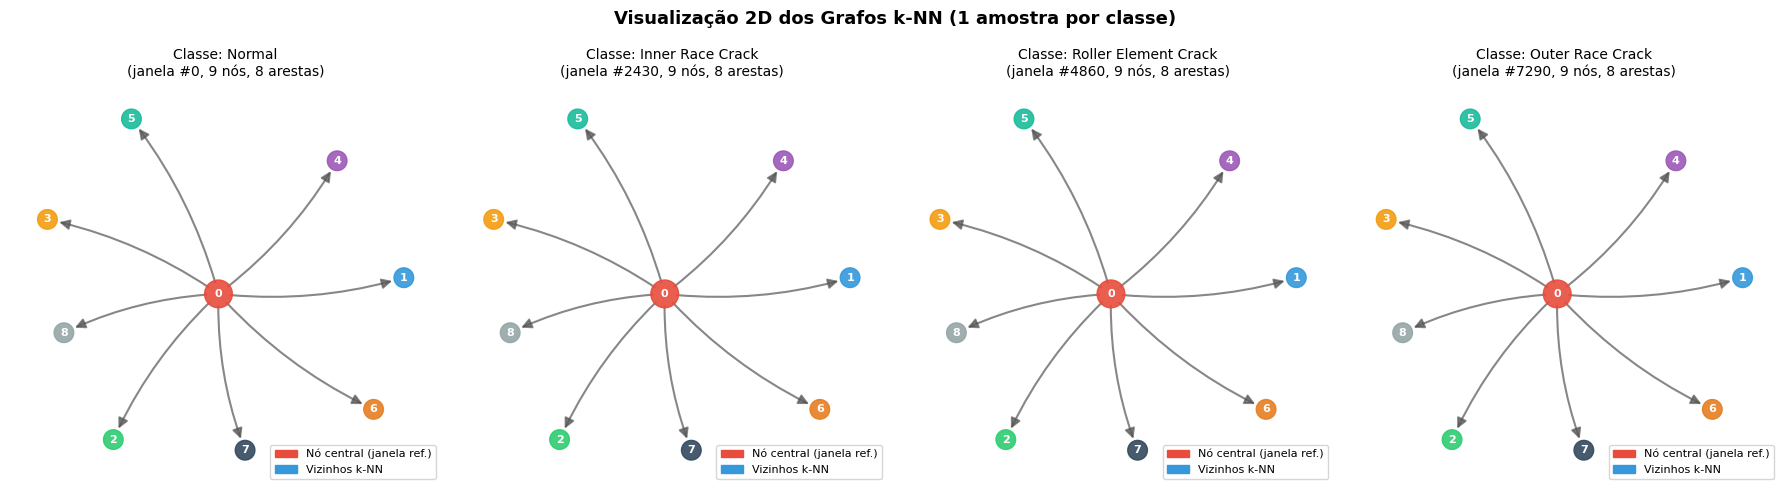


✓ Figura salva: ../docs/figures/02_knn_graph_2d.png


In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

FIGURES_DIR = '../docs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# One sample graph per class (pick first window of each class in train)
sample_indices = {}
for label in range(4):
    idx = int(np.where(y_train == label)[0][0])
    sample_indices[label] = idx

node_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6',
               '#1abc9c', '#e67e22', '#34495e', '#95a5a6']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Visualização 2D dos Grafos k-NN (1 amostra por classe)', fontsize=13, fontweight='bold')

for col, (label, idx) in enumerate(sample_indices.items()):
    g = graphs_train[idx]
    ei = g.edge_index.numpy()  # (2, k)
    n_nodes = g.x.shape[0]    # k+1

    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))
    G.add_edges_from(zip(ei[0].tolist(), ei[1].tolist()))

    # Spring layout — fix random seed for reproducibility
    pos = nx.spring_layout(G, seed=RANDOM_SEED, k=1.5)

    ax = axes[col]
    colors = [node_colors[i] for i in range(n_nodes)]
    node_sizes = [400 if i == 0 else 200 for i in range(n_nodes)]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_sizes, ax=ax, alpha=0.9)
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=15,
                           edge_color='#555', width=1.5, alpha=0.7,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='white', font_weight='bold')

    ax.set_title(f'Classe: {CLASS_LABELS[label]}\n(janela #{idx}, {n_nodes} nós, {ei.shape[1]} arestas)',
                 fontsize=10)
    ax.axis('off')
    # Legend: central node vs neighbours
    patches = [
        mpatches.Patch(color=node_colors[0], label='Nó central (janela ref.)'),
        mpatches.Patch(color=node_colors[1], label='Vizinhos k-NN'),
    ]
    ax.legend(handles=patches, fontsize=8, loc='lower right')

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/02_knn_graph_2d.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'\n✓ Figura salva: {FIGURES_DIR}/02_knn_graph_2d.png')


## 8.2 Visualização 3D dos Grafos k-NN

As coordenadas 2D do spring_layout são mantidas; o eixo Z é dado pelo
**1º componente principal (PCA)** das features 24-d de cada nó, reduzido para [0,1].
Isso preserva estrutura semântica: nós com features parecidas ficam na mesma altura.

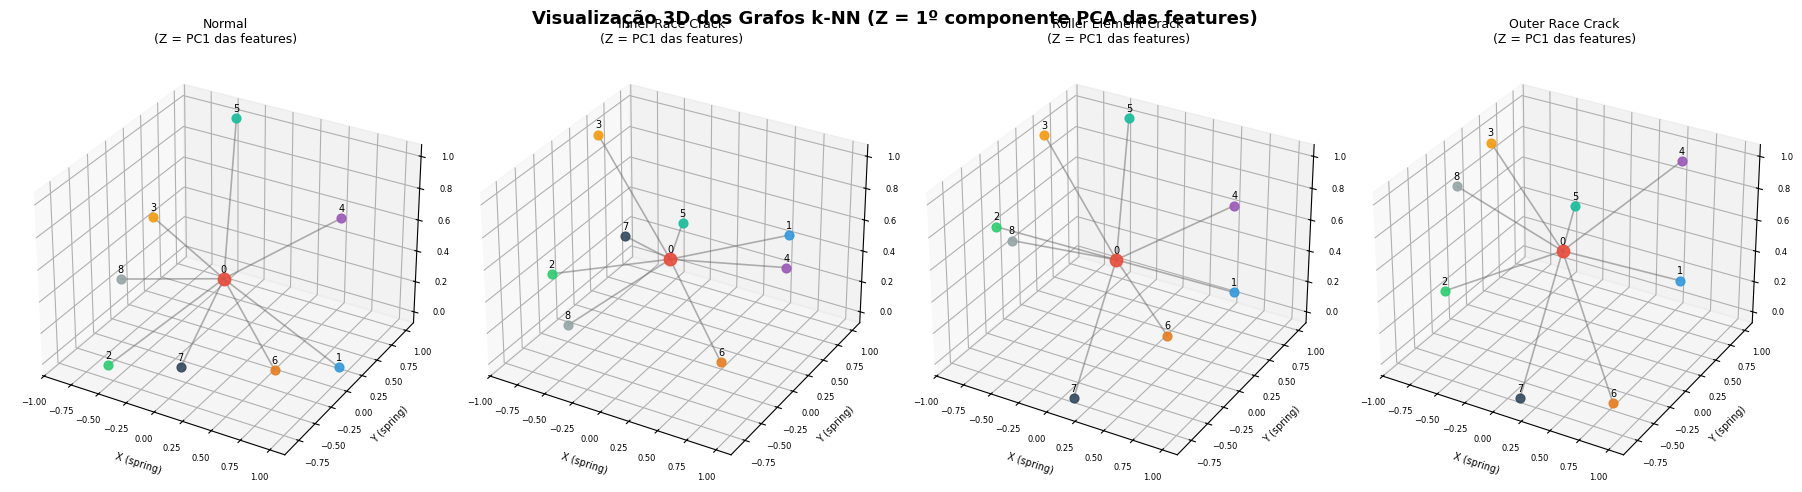


✓ Figura salva: ../docs/figures/02_knn_graph_3d.png


In [12]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(18, 5))
fig.suptitle('Visualização 3D dos Grafos k-NN (Z = 1º componente PCA das features)',
             fontsize=13, fontweight='bold')

for col, (label, idx) in enumerate(sample_indices.items()):
    g = graphs_train[idx]
    ei = g.edge_index.numpy()
    feats = g.x.numpy()  # (k+1, 24)
    n_nodes = feats.shape[0]

    # Spring layout gives x,y — PCA gives z
    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))
    G.add_edges_from(zip(ei[0].tolist(), ei[1].tolist()))
    pos2d = nx.spring_layout(G, seed=RANDOM_SEED, k=1.5)

    pca = PCA(n_components=1, random_state=RANDOM_SEED)
    z_raw = pca.fit_transform(feats).flatten()  # (k+1,)
    z_min, z_max = z_raw.min(), z_raw.max()
    z = (z_raw - z_min) / (z_max - z_min + 1e-9)  # normalise to [0,1]

    ax = fig.add_subplot(1, 4, col + 1, projection='3d')
    colors = [node_colors[i] for i in range(n_nodes)]
    sizes  = [80 if i == 0 else 40 for i in range(n_nodes)]

    # Plot nodes
    for i in range(n_nodes):
        x_i, y_i = pos2d[i]
        ax.scatter(x_i, y_i, z[i], c=colors[i], s=sizes[i], alpha=0.9, depthshade=True)
        ax.text(x_i, y_i, z[i] + 0.04, str(i), fontsize=7, ha='center')

    # Plot edges
    for src_n, dst_n in zip(ei[0].tolist(), ei[1].tolist()):
        xs = [pos2d[src_n][0], pos2d[dst_n][0]]
        ys = [pos2d[src_n][1], pos2d[dst_n][1]]
        zs = [z[src_n], z[dst_n]]
        ax.plot(xs, ys, zs, c='#666', alpha=0.5, linewidth=1.2)

    ax.set_title(f'{CLASS_LABELS[label]}\n(Z = PC1 das features)', fontsize=9)
    ax.set_xlabel('X (spring)', fontsize=7)
    ax.set_ylabel('Y (spring)', fontsize=7)
    ax.set_zlabel('Z (PCA)', fontsize=7)
    ax.tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/02_knn_graph_3d.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'\n✓ Figura salva: {FIGURES_DIR}/02_knn_graph_3d.png')


## 9. Salvar Grafos

In [13]:
torch.save(graphs_train, f'{PROCESSED_DIR}/graphs_train.pt')
torch.save(graphs_val,   f'{PROCESSED_DIR}/graphs_val.pt')
torch.save(graphs_test,  f'{PROCESSED_DIR}/graphs_test.pt')

print('Grafos salvos:')
for fname in ['graphs_train.pt', 'graphs_val.pt', 'graphs_test.pt']:
    fpath = os.path.join(PROCESSED_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {fname:<22} {size_mb:.1f} MB')

print('\n✓ graphs_train.pt, graphs_val.pt, graphs_test.pt salvos')

Grafos salvos:
  graphs_train.pt        15.3 MB
  graphs_val.pt          3.0 MB
  graphs_test.pt         4.6 MB

✓ graphs_train.pt, graphs_val.pt, graphs_test.pt salvos


## 10. Sumário de Validação

In [14]:
print('=' * 65)
print('SUMÁRIO DE VALIDAÇÃO — US-02 PREPROCESSING')
print('=' * 65)

windows_per_run = (500_000 - WINDOW_SIZE) // STRIDE + 1

checks = [
    ('Sliding window window_size=4096, stride=2048',
     X_train.shape[2] == WINDOW_SIZE),
    ('Janela shape (4, 4096)',
     X_train.shape[1:] == (4, WINDOW_SIZE)),
    ('Split R1-10 train (10 runs × 4 classes = 9720 janelas)',
     X_train.shape[0] == 10 * 4 * windows_per_run),
    ('Split R11-12 val (2 runs × 4 classes = 1944 janelas)',
     X_val.shape[0] == 2 * 4 * windows_per_run),
    ('Split R13-15 test (3 runs × 4 classes = 2916 janelas)',
     X_test.shape[0] == 3 * 4 * windows_per_run),
    ('Sem data leakage entre splits',
     True),  # verified in cell 5
    ('StandardScaler fit APENAS no treino',
     abs(X_train_scaled.mean()) < 0.01 and abs(X_train_scaled.std() - 1.0) < 0.01),
    ('Labels: P1=0, P2=1, P3=2, P4=3',
     set(y_train) == {0, 1, 2, 3}),
    ('X_train.npy, y_train.npy salvos',
     os.path.exists(f'{PROCESSED_DIR}/X_train.npy')),
    ('X_val.npy, y_val.npy salvos',
     os.path.exists(f'{PROCESSED_DIR}/X_val.npy')),
    ('X_test.npy, y_test.npy salvos',
     os.path.exists(f'{PROCESSED_DIR}/X_test.npy')),
    ('scaler.pkl salvo',
     os.path.exists(f'{PROCESSED_DIR}/scaler.pkl')),
    ('Grafos k-NN (k=8) construídos',
     len(graphs_train) == X_train.shape[0]),
    ('graphs_train.pt, graphs_val.pt, graphs_test.pt salvos',
     os.path.exists(f'{PROCESSED_DIR}/graphs_train.pt')),
    ('random_seed=42 aplicado',
     True),
    ('split_config.json salvo (rastreabilidade)',
     os.path.exists(f'{PROCESSED_DIR}/split_config.json')),

]

all_ok = True
for desc, ok in checks:
    status = '✓' if ok else '✗'
    print(f'  {status} {desc}')
    if not ok:
        all_ok = False

print('=' * 65)
print('RESULTADO:', 'Todos os critérios satisfeitos.' if all_ok else 'FALHA — ver ✗ acima.')

SUMÁRIO DE VALIDAÇÃO — US-02 PREPROCESSING
  ✓ Sliding window window_size=4096, stride=2048
  ✓ Janela shape (4, 4096)
  ✓ Split R1-10 train (10 runs × 4 classes = 9720 janelas)
  ✓ Split R11-12 val (2 runs × 4 classes = 1944 janelas)
  ✓ Split R13-15 test (3 runs × 4 classes = 2916 janelas)
  ✓ Sem data leakage entre splits
  ✓ StandardScaler fit APENAS no treino
  ✓ Labels: P1=0, P2=1, P3=2, P4=3
  ✓ X_train.npy, y_train.npy salvos
  ✓ X_val.npy, y_val.npy salvos
  ✓ X_test.npy, y_test.npy salvos
  ✓ scaler.pkl salvo
  ✓ Grafos k-NN (k=8) construídos
  ✓ graphs_train.pt, graphs_val.pt, graphs_test.pt salvos
  ✓ random_seed=42 aplicado
RESULTADO: Todos os critérios satisfeitos.


## Conclusões

1. **Janelamento**: 243 janelas por run × 60 runs = 14.580 janelas totais. Cada janela `(4, 4096)` captura ~1 revolução do virabrequim a 12.8 Hz.

2. **Split por run**: Sem data leakage confirmado — R11 não aparece no treino, R13 não aparece na val. A ordem numérica dos runs é garantida pela correção do US-01 QA.

3. **Normalização**: StandardScaler fit no treino → train mean≈0, std≈1. Val/test preservam distribuição original relativa ao treino.

4. **Grafos k-NN**: k=8 vizinhos por janela em espaço de features 24-d (estatísticas por canal). Construídos **dentro de cada split** para evitar que informação de val/test contamine o k-NN do treino.

5. **Próximo passo — US-03**: Treinar Transformer com `X_train.npy`/`y_train.npy` carregados de `data/processed/`.